# Supplementary 1 Choice model comparison

## Preference model comparison

To investigate the relationship between task structures and participants preferences, we fitted a model in which we fitted a latent preference score computed as the weighted sum of regressors associated with each factors of our task (offers, energy, current and future costs) where the weight associated with each are estimated from participants data. In addition, the model comprised a fixed effect for the decision values derived from reinforcement learning (RL) backward induction method to represent the behaviour of an optimal planner, as well as an interaction between the decision values and the entropy of the preferences scores, to investigate whether participants reliance on planning depends on the strength of their preferences. 

This model was observed to fit the data best, showing that participants behaviour reflects the integration of a planning component together with priors reflecting the structure of the task, shedding light on the structure of the priors themselves. To further show that participants priors reflect the whole structure of the task, we modelled the data removing one experimental factor from the preferences fitting one at a time and compared to the full model, to show that our results cannot be explained by the fact that participants's priors do not reflect a single nor a subset of experimental factors.

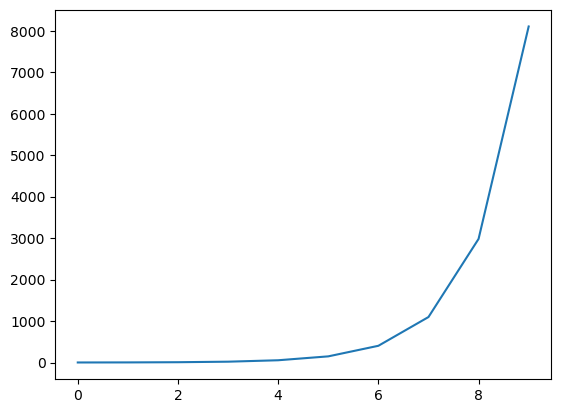

In [2]:
# Import all packages

# General utilities:
import os 
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

# Stats
import pymc as pm
import arviz as az
import bambi as bmb
from scipy.special import logit

# Custom packages:
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
from stabst.utils import avg_reduce_mdp, abstract2ground_value

# Set random seed for reproducibility:
np.random.seed(42)
warnings.filterwarnings("ignore")

n_samples = 1000
n_warmup = 1000
n_chains = 4

control_models_path = "./data/bids/limited_energy/derivatives/control_models/"
if not os.path.exists(control_models_path):
    os.makedirs(control_models_path)

# Choice behaviour model with preferences and decision values:
def preference_model(
        y: np.array,
        decision_values: np.array,
        pref_regressors: pd.DataFrame,
        subject_index: np.array,
        subject_labels: np.array      
):
    '''
    Parameters
    ----------
    y : np.array [N samples, ]
        Observed binary data (1, 0...)
    decision_values : np.array [N samples, ]
        Decision values to regress onto the observed data
    pref_regressors : np.array [N samples, M regressors]
        Regressor to fit participants preference for. We can have M regressors
    subject_index : np.array  [N samples, ]
        Index of the subject associated with each observation
    subject_labels : np.array  [N subjects, ]
        Single identifier of each subject
    coords : dict  
        "subject": subj_labels, 
        "coef": ["intercept", "slope"],
        The subject maps the data to each subject, the coef are for the coefficients
    b_prior_mean : Optional[float], optional
        Prior mean of each beta parameters, by default 0
    b_prior_sigma : Optional[float], optional
        Prior variance of the population level distribution of the beta, by default 2
    s_prior_sigma : Optional[float], optional
        Prior between subjects variance, by default 2
    n_drawss : Optional[int], optional
        Number of draws for the posterior, by default 1000
    n_tuning_draws : Optional[int], optional
        Number of tuning draws, by default 1000
    Returns
    -------
    tuple[pm.Model, arviz.InferenceData]
        pm.model : pymc model object
        idata : arviz inference data
    """
    '''
    # Get dimensions:
    n_obs = y.shape[0]
    n_groups = subject_labels.shape[0]
    n_pref = pref_regressors.shape[1]

    # Create intercept:
    intercept = np.ones(n_obs)

    # Set coordinates:
    coords = {
        "subject": subject_labels,
        "coef_intercept": ["B_intercept"],
        "coef_planning": ["B_plan"],
        "coef_pref": ["B_" + col for col in pref_regressors.columns],
        "coef_interaction": ["slope"],
    }


    # Model:
    with pm.Model(coords=coords) as planning_preferences_interaction_model:
        # Data:
        y_obs = pm.Data("y_obs", y)
        intercept = pm.Data("intercept", intercept)
        planning = pm.Data("planning", decision_values)
        preferences = pm.Data("preferences", pref_regressors)
        subj_idx = pm.Data("subj_idx", subject_index.astype("int32"))

        # Hyperpriors:
        # Intercept term
        beta_intercept = pm.Normal("beta_intercept", mu=0, sigma=2, dims="coef_intercept")
        sigma_intercept = pm.HalfNormal("sigma_intercept", sigma=2, dims="coef_intercept")
        # Planning term:
        beta_planning = pm.Normal("beta_planning", mu=0, sigma=2, dims="coef_planning")
        sigma_planning = pm.HalfNormal("sigma_planning", sigma=2, dims="coef_planning")
        # Preference terms:
        beta_pref = pm.Normal("beta_pref", mu=0, sigma=2, dims="coef_pref")
        sigma_pref = pm.HalfNormal("sigma_pref", sigma=2, dims="coef_pref")
        # Interaction term:
        beta_interaction = pm.Normal("beta_interaction", mu=0, sigma=2, dims="coef_interaction")
        sigma_interaction = pm.HalfNormal("sigma_interaction", sigma=2, dims="coef_interaction")

        # Offset parameters:
        z_intercept = pm.Normal("z_intercept", 0, 1, dims=("subject", "coef_intercept"))
        z_planning = pm.Normal("z_planning", 0, 1, dims=("subject", "coef_planning"))
        z_biases = pm.Normal("z_biases", 0, 1, dims=("subject", "coef_pref"))
        z_interaction = pm.Normal("z_interaction", 0, 1, dims=("subject", "coef_interaction"))

        # Centered parameters:
        beta_intercept_sub = pm.Deterministic("beta_intercept_sub", beta_intercept + z_intercept * sigma_intercept, 
                                              dims=("subject", "coef_intercept"))
        beta_planning_sub = pm.Deterministic("beta_planning_sub", beta_planning + z_planning * sigma_planning, 
                                             dims=("subject", "coef_planning"))
        beta_pref_sub = pm.Deterministic("beta_pref_sub", beta_pref + z_biases * sigma_pref, 
                                         dims=("subject", "coef_pref"))
        beta_interaction_sub = pm.Deterministic("beta_interaction_sub", beta_interaction + z_interaction * sigma_interaction, 
                                                dims=("subject", "coef_interaction"))
        
        # Estimate the score of the bias (i.e. weighted sum of each of the biases regressors):
        preference = pm.Deterministic('preference', (beta_pref_sub[subj_idx] * preferences).sum(axis=-1))
        
        # Convert the bias back onto probability space:
        pi_prior = pm.Deterministic("pi_prior", pm.math.sigmoid(preference))

        # Compute the entropy:
        entropy = pm.Deterministic("entropy", -pi_prior * pm.math.log(pi_prior) - (1-pi_prior) * pm.math.log(1 - pi_prior))
        
        # Eta parameter is the weighted sum of the intercept, the bias, the planning values and 
        # the interaction between the entropy of the bias and the planning
        eta = (
            beta_intercept_sub[subj_idx, 0] * intercept
            + preference
            + beta_planning_sub[subj_idx, 0] * planning
            + beta_interaction_sub[subj_idx, 0] * (entropy * planning)
        )
        
        # Expected values:
        p = pm.Deterministic("p", pm.math.sigmoid(eta))

        # Likelihood 
        pm.Bernoulli("y", p=p, observed=y_obs)

        # Sampling:
        idata = pm.sample(
            draws=n_samples,
            tune=n_warmup,
            chains=n_chains,
            target_accept=0.85,
            idata_kwargs={"log_likelihood": True},
        )

    return idata


def linear_decay_mvavg(arr, window_size, init_val = 0.5, kernel="linear"):
    '''
    Compute the moving average of a 1D array with a specified window size and 
    linear decay
    '''
    # Pad the array with initial value
    padded_arr = np.pad(arr.astype(float), (window_size - 1, 0), constant_values=init_val)
    # Generate kernel:
    if kernel.lower() == "linear":
        kern = np.arange(window_size)/np.sum(np.arange(window_size))
    elif kernel.lower() == "exponential":
        kern = np.exp(np.arange(window_size))/np.sum(np.exp(np.arange(window_size)))
    conv_result = np.convolve(padded_arr, kern, mode='valid')
    res = np.full(len(arr), init_val)
    # For t >= k, we can use conv_result[t-1]
    for t in range(window_size, len(arr)):
        res[t] = conv_result[t-1]
    return res

fig, ax = plt.subplots()
ax.plot(np.arange(10), np.exp(np.arange(10)))
plt.show();

## Preparing the data:
We apply the exact same preprocessing as in the manuscript notebook

In [3]:
# Download the data if needed:
if not os.path.exists('../data/raw_data/all_participants_data.csv'):
    if not os.path.exists('../data/raw_data'):
        os.makedirs('../data/raw_data')
    url = 'https://raw.githubusercontent.com/fmott/context_dependent_planning/4d239b721749adabb8fe8f1d8ac2d1ecdeba17cf/data/behaviour/data_all_participants_20220215120148.csv'
    os.system(f'wget {url} -O ../data/raw_data/all_participants_data.csv')
if not os.path.exists('../data/raw_data/all_participants_age_gender.csv'):
    if not os.path.exists('../data/raw_data'):
        os.makedirs('../data/raw_data')
    url = 'https://raw.githubusercontent.com/fmott/context_dependent_planning/4d239b721749adabb8fe8f1d8ac2d1ecdeba17cf/data/behaviour/age_gender.csv'
    os.system(f'wget {url} -O ../data/raw_data/all_participants_age_gender.csv')
# Load the data:
beh_data = pd.read_csv('../data/raw_data/all_participants_data.csv')
demographic_data = pd.read_csv('../data/raw_data/all_participants_age_gender.csv', sep=";")

# Extract demographic information:
n_participants = demographic_data.shape[0]
n_female = demographic_data['gender (m = 1, f = 2)'].value_counts()[2]
mean_age = demographic_data['age'].mean()
std_age = demographic_data['age'].std()

# ===================================================================
# Data preprocessing:
# Remove nans:
beh_data = beh_data.dropna()
# Remove timeout:
beh_data = beh_data[beh_data["timeout"] == 0]
# Flip responses: 1 = accept:
beh_data["response"] = (beh_data["response"] == 0).astype(int)
# Make trial 1 based
beh_data["trial"] = beh_data["trial"] + 1
# Generate future cost based on the transitions:
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
beh_data["fc"] = [transitions_costs[row["transition"]][1] for _, row in beh_data.iterrows()]

# ===================================================================
# Prepare the decision values:
# Task MDP:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 1
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()

# Add decision values to the data frame:
dv = Q_full[:, 1] - Q_full[:, 0]
# Loop through each trial to set DV:
dv_trials = []
for trial_i, trial in beh_data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
beh_data['dv'] = dv_trials
# Compute offer specific decision value regressors:
beh_data['dv_23'] = beh_data['dv'].to_numpy() * (beh_data['is_2'].to_numpy() + beh_data['is_3'].to_numpy())
beh_data['dv_14'] = beh_data['dv'].to_numpy() * (beh_data['is_1'].to_numpy() + beh_data['is_4'].to_numpy())

# ===================================================================
# Preparing regressors:
# Categorical offer regressor for high and low offer
beh_data['is_12'] = beh_data['is_1'].to_numpy() + beh_data['is_2'].to_numpy()
beh_data['is_34'] = beh_data['is_3'].to_numpy() + beh_data['is_4'].to_numpy()
# Continuous regressor for high and low offer:
beh_data['high_vs_low'] = beh_data['is_34'] - beh_data['is_12']

# Categorical costs regressor
beh_data['is_lc'] = (beh_data['energy_cost'] == 1).astype(int).to_numpy()
beh_data['is_hc'] = (beh_data['energy_cost'] == 2).astype(int).to_numpy()
# Categorical future costs regressor
beh_data['is_lfc'] = (beh_data['fc'] == 1).astype(int).to_numpy()
beh_data['is_hfc'] = (beh_data['fc'] == 2).astype(int).to_numpy()

# Categorical transition regressor
beh_data['is_trans1'] = (beh_data['transition'] == 0).to_numpy()
beh_data['is_trans2'] = (beh_data['transition'] == 1).to_numpy()
beh_data['is_trans3'] = (beh_data['transition'] == 2).to_numpy()
beh_data['is_trans4'] = (beh_data['transition'] == 3).to_numpy()

# Categorical energy regressor:
beh_data['e_is_0'] = (beh_data['energy'] == 0).to_numpy()
beh_data['e_is_1'] = (beh_data['energy'] == 1).to_numpy()
beh_data['e_is_2'] = (beh_data['energy'] == 2).to_numpy()
beh_data['e_is_3'] = (beh_data['energy'] == 3).to_numpy()
beh_data['e_is_4'] = (beh_data['energy'] == 4).to_numpy()
beh_data['e_is_5'] = (beh_data['energy'] == 5).to_numpy()
beh_data['e_is_6'] = (beh_data['energy'] == 6).to_numpy()

# Random effects
subj_idx_raw, subj_labels = pd.factorize(beh_data["vpn"])

## Fitting the full model
First, we fit the full model, which will then be compared to reduced models:

In [4]:
# Fitting the models:
traces = {}
# ===================================================================
# Preference model:
if os.path.exists("./data/bids/limited_energy/derivatives/models/preferences_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/models/preferences_model_trace.nc")
    traces['full_preferences_model'] = idata
else:
    raise Exception("Make sure to run the index notebook first!")

## Compute models removing each factors from the preferences:
Then, we compute the same model, but removing each factors from the task when computing the preferences:

In [5]:
# ===================================================================
# Model without offer related preferences:
if os.path.exists(Path(control_models_path, "preferences_model_no_offer_trace.nc")):
    idata = az.from_netcdf(Path(control_models_path, "preferences_model_no_offer_trace.nc"))
    traces['No_Offer'] = idata
else:
    preference_columns = [
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc',
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces['No_Offer'] = idata
    # Save the trace to file:
    az.to_netcdf(traces['No_Offer'], Path(control_models_path, "preferences_model_no_offer_trace.nc"))

# ===================================================================
# Model without current costs related preferences:
if os.path.exists(Path(control_models_path, "preferences_model_no_costs_trace.nc")):
    idata = az.from_netcdf(Path(control_models_path, "preferences_model_no_costs_trace.nc"))
    traces['No_CC'] = idata
else:
    # Fit the model without the costs related preferences:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lfc', 'is_hfc',
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces['No_CC'] = idata
    # Save the trace to file:
    az.to_netcdf(traces['No_CC'], Path(control_models_path, "preferences_model_no_costs_trace.nc"))

# ===================================================================
# Model without future costs related preferences:
if os.path.exists(Path(control_models_path, "preferences_model_no_future_costs_trace.nc")):
    idata = az.from_netcdf(Path(control_models_path, "preferences_model_no_future_costs_trace.nc"))
    traces['No_FC'] = idata
else:
    # Fit the model without the future costs related preferences:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces['No_FC'] = idata
    # Save the trace to file:
    az.to_netcdf(traces['No_FC'], Path(control_models_path, "preferences_model_no_future_costs_trace.nc"))

# ===================================================================
# Model without energy related preferences:
if os.path.exists(Path(control_models_path, "preferences_model_no_energy_trace.nc")):
    idata = az.from_netcdf(Path(control_models_path, "preferences_model_no_energy_trace.nc"))
    traces['No_Energy'] = idata
else:
    # Fit the model without the energy related preferences:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'is_trans1', 'is_trans2', 'is_trans3', 'is_trans4', 
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces['No_Energy'] = idata
    # Save the trace to file:
    az.to_netcdf(traces['No_Energy'], Path(control_models_path, "preferences_model_no_energy_trace.nc"))

## Model without decision values
In addition, we compared the full preference model with a model without decision values. This is to investigate whether participants behaviour might not rely on any sort of optimal planning but on simpler heuristic based on the structure of the task:

In [6]:
if os.path.exists(Path(control_models_path, "no_planning_model.nc")):
    idata = az.from_netcdf(Path(control_models_path, "no_planning_model.nc"))
    traces['No_Planning'] = idata
else:
    # Choice behaviour model with prefences only, no decision values:
    pref_regressors = beh_data[[
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc',
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]]

    # Create intercept:
    intercept = np.ones(beh_data.shape[0])

    # Set coordinates:
    coords = {
        "subject": subj_labels,
        "coef_intercept": ["B_intercept"],
        "coef_planning": ["B_plan"],
        "coef_pref": ["B_" + col for col in pref_regressors.columns],
        "coef_interaction": ["slope"],
    }

    # Model:
    with pm.Model(coords=coords) as preference_model:
        # Data:
        y_obs = pm.Data("y_obs", beh_data['response'])
        intercept = pm.Data("intercept", intercept)
        preferences = pm.Data("preferences", pref_regressors)
        subj_idx = pm.Data("subj_idx", subj_idx_raw.astype("int32"))

        # Hyperpriors:
        # Intercept term
        beta_intercept = pm.Normal("beta_intercept", mu=0, sigma=2, dims="coef_intercept")
        sigma_intercept = pm.HalfNormal("sigma_intercept", sigma=2, dims="coef_intercept")
        # Preference terms:
        beta_pref = pm.Normal("beta_pref", mu=0, sigma=2, dims="coef_pref")
        sigma_pref = pm.HalfNormal("sigma_pref", sigma=2, dims="coef_pref")

        # Offset parameters:
        z_intercept = pm.Normal("z_intercept", 0, 1, dims=("subject", "coef_intercept"))
        z_biases = pm.Normal("z_biases", 0, 1, dims=("subject", "coef_pref"))

        # Centered parameters:
        beta_intercept_sub = pm.Deterministic("beta_intercept_sub", beta_intercept + z_intercept * sigma_intercept, 
                                                dims=("subject", "coef_intercept"))
        beta_pref_sub = pm.Deterministic("beta_pref_sub", beta_pref + z_biases * sigma_pref, 
                                            dims=("subject", "coef_pref"))
        
        # Estimate the score of the bias (i.e. weighted sum of each of the biases regressors):
        preference = pm.Deterministic('preference', (beta_pref_sub[subj_idx] * preferences).sum(axis=-1))

        # Eta parameter is the weighted sum of the intercept, the bias, the planning values and 
        # the interaction between the entropy of the bias and the planning
        eta = (
            beta_intercept_sub[subj_idx, 0] * intercept
            + preference
        )
        
        # Expected values:
        p = pm.Deterministic("p", pm.math.sigmoid(eta))

        # Likelihood 
        pm.Bernoulli("y", p=p, observed=y_obs)

        # Sampling:
        traces['No_Planning'] = pm.sample(
            draws=n_samples,
            tune=n_warmup,
            chains=n_chains,
            target_accept=0.85,
            idata_kwargs={"log_likelihood": True},
        )
        # Save to file:
        az.to_netcdf(traces['No_Planning'], Path(control_models_path, "no_planning_model.nc"))

## Model without interactions
Finally, we also test a model without interaction between preferences entropy and decision values.

In [7]:
if os.path.exists(Path(control_models_path, "no_interaction_model.nc")):
    idata = az.from_netcdf(Path(control_models_path, "no_interaction_model.nc"))
    traces['No_Interaction'] = idata
else:
    # Choice behaviour model with prefences only, no decision values:
    pref_regressors = beh_data[[
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc',
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]]

    # Create intercept:
    intercept = np.ones(beh_data.shape[0])

    # Set coordinates:
    coords = {
        "subject": subj_labels,
        "coef_intercept": ["B_intercept"],
        "coef_planning": ["B_plan"],
        "coef_pref": ["B_" + col for col in pref_regressors.columns],
        "coef_interaction": ["slope"],
    }

    # Model:
    with pm.Model(coords=coords) as no_interaction_model:
        # Data:
        y_obs = pm.Data("y_obs", beh_data['response'])
        intercept = pm.Data("intercept", intercept)
        planning = pm.Data("planning", np.squeeze(beh_data[['dv']].to_numpy()))
        preferences = pm.Data("preferences", pref_regressors)
        subj_idx = pm.Data("subj_idx", subj_idx_raw.astype("int32"))

        # Hyperpriors:
        # Intercept term
        beta_intercept = pm.Normal("beta_intercept", mu=0, sigma=2, dims="coef_intercept")
        sigma_intercept = pm.HalfNormal("sigma_intercept", sigma=2, dims="coef_intercept")
        # Planning term:
        beta_planning = pm.Normal("beta_planning", mu=0, sigma=2, dims="coef_planning")
        sigma_planning = pm.HalfNormal("sigma_planning", sigma=2, dims="coef_planning")
        # Preference terms:
        beta_pref = pm.Normal("beta_pref", mu=0, sigma=2, dims="coef_pref")
        sigma_pref = pm.HalfNormal("sigma_pref", sigma=2, dims="coef_pref")

        # Offset parameters:
        z_intercept = pm.Normal("z_intercept", 0, 1, dims=("subject", "coef_intercept"))
        z_planning = pm.Normal("z_planning", 0, 1, dims=("subject", "coef_planning"))
        z_biases = pm.Normal("z_biases", 0, 1, dims=("subject", "coef_pref"))

        # Centered parameters:
        beta_intercept_sub = pm.Deterministic("beta_intercept_sub", beta_intercept + z_intercept * sigma_intercept, 
                                                dims=("subject", "coef_intercept"))
        beta_planning_sub = pm.Deterministic("beta_planning_sub", beta_planning + z_planning * sigma_planning, 
                                                dims=("subject", "coef_planning"))
        beta_pref_sub = pm.Deterministic("beta_pref_sub", beta_pref + z_biases * sigma_pref, 
                                            dims=("subject", "coef_pref"))
        
        # Estimate the score of the bias (i.e. weighted sum of each of the biases regressors):
        preference = pm.Deterministic('preference', (beta_pref_sub[subj_idx] * preferences).sum(axis=-1))

        # Eta parameter is the weighted sum of the intercept, the bias, the planning values and 
        # the interaction between the entropy of the bias and the planning
        eta = (
            beta_intercept_sub[subj_idx, 0] * intercept
            + beta_planning_sub[subj_idx, 0] * planning
            + preference
        )
        
        # Expected values:
        p = pm.Deterministic("p", pm.math.sigmoid(eta))

        # Likelihood 
        pm.Bernoulli("y", p=p, observed=y_obs)

        # Sampling:
        traces['No_Interaction'] = pm.sample(
            draws=n_samples,
            tune=n_warmup,
            chains=n_chains,
            target_accept=0.85,
            idata_kwargs={"log_likelihood": True},
        )

        az.to_netcdf(traces['No_Interaction'], Path(control_models_path, "no_interaction_model.nc"))

## Comparing the models:

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
full_preferences_model,0,-1491.091155,253.490122,0.000000,7.589529e-01,48.615646,0.000000,True,log
No_Interaction,1,-1501.438309,245.860995,10.347154,5.733417e-15,48.910290,5.418092,True,log
No_FC,2,-1517.792877,227.725070,26.701722,9.830322e-15,48.535449,7.599396,True,log
No_CC,3,-1539.490753,262.803473,48.399597,1.728439e-14,49.889247,9.677248,True,log
No_Planning,4,-1581.229261,217.308042,90.138106,1.559356e-01,48.803948,17.226217,True,log
No_Energy,5,-1626.441742,211.154968,135.350587,4.964563e-02,51.568217,17.853538,True,log
No_Offer,6,-1629.835751,235.202668,138.744596,3.546586e-02,54.438208,19.332967,True,log


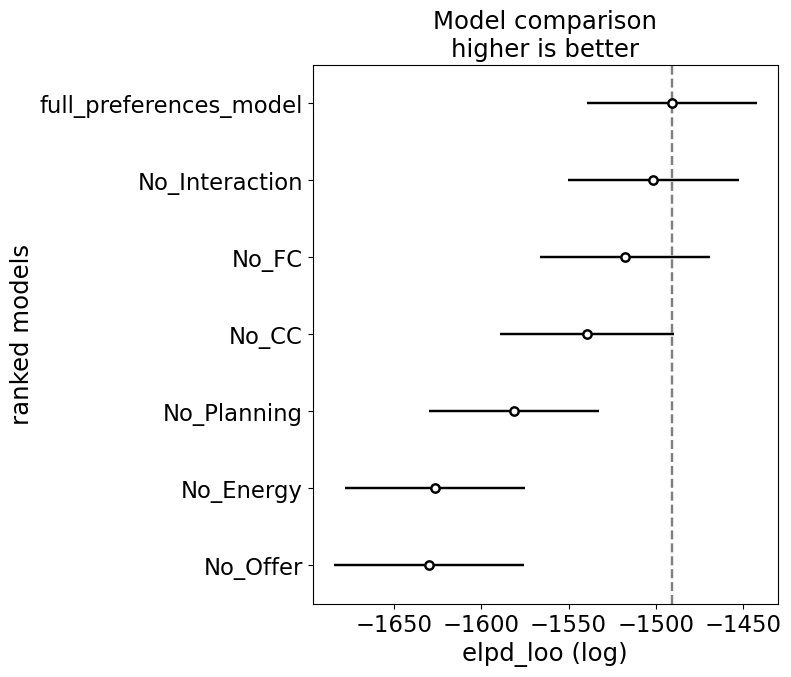

In [8]:
# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

## Frequency prior model comparison
In the main text, we compared the preference model with a model in which priors are computed based on action frequency. In this model, the priors are computed using a linearly decaying moving average, discounting actions that occured further in the past. We presented the results obtained when the priors are derived from the XXX previous trials. This number of trials was selected by exploring priors witk $k=[2, 5, 10, 15, 20, 30, 50]$ to identify the values that fit the data the best:

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
"Linear, k=20",0,-2069.603756,78.387251,0.000000,5.525676e-01,55.685833,0.000000,False,log
"Linear, k=15",1,-2073.741747,74.270280,4.137991,1.564493e-01,55.887831,5.240833,False,log
"Linear, k=2",2,-2074.978233,75.567712,5.374477,2.909832e-01,55.683306,6.296650,False,log
"Linear, k=5",3,-2076.303091,78.839970,6.699335,0.000000e+00,55.648421,5.581387,False,log
"Linear, k=10",4,-2077.335887,74.064255,7.732131,0.000000e+00,55.534071,5.653286,False,log
"Linear, k=50",5,-2080.708924,78.790183,11.105168,3.115964e-14,55.716113,5.095259,False,log
"Linear, k=30",6,-2081.095963,75.785958,11.492207,2.691895e-14,55.760237,5.469725,False,log


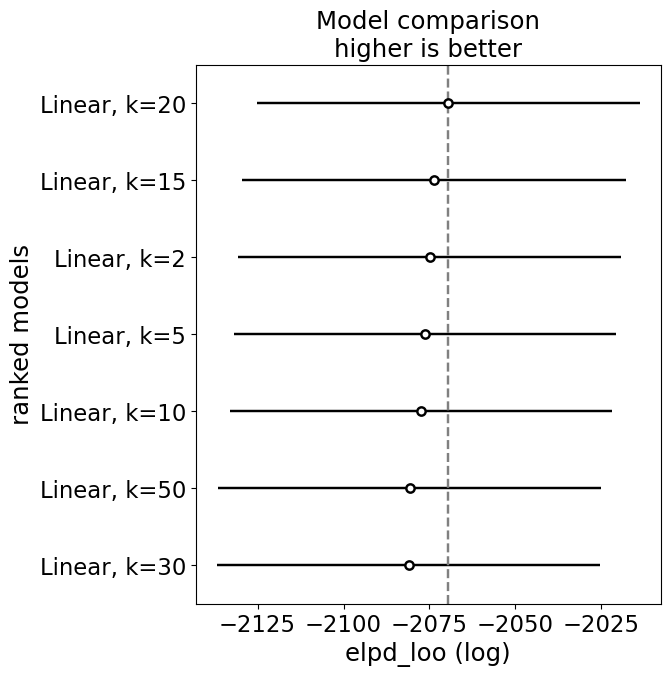

In [9]:
traces = {}
for k in [2, 5, 10, 15, 20, 30, 50]:
    if os.path.exists(Path(control_models_path, f"linear_freq_prior_k{k}.nc")):
        idata = az.from_netcdf(Path(control_models_path, f"linear_freq_prior_k{k}.nc"))
        traces[f'Linear, k={k}'] = idata
    else:
        # Compute action priors:
        P_A = []
        for subj in beh_data['vpn'].unique():
            sub_resp = beh_data[beh_data['vpn'] == subj]['response'].to_numpy()
            P_A.append(linear_decay_mvavg(sub_resp, window_size=k, init_val=0.5))
        data = pd.DataFrame(
            {
            'response': beh_data['response'],
            'vpn': beh_data['vpn'],
            'dv': beh_data['dv'],
            'logitP_A': logit(np.clip(np.concatenate(P_A), 1e-3, 1-1e-3))
            }
        )
        action_prior_model = bmb.Model(
            "response ~ dv + logitP_A + dv:logitP_A +"
            " + (dv + logitP_A|vpn)",
                data, 
                family="bernoulli"
            )
        # Add the idata to the rest:
        traces[f'Linear, k={k}'] = action_prior_model.fit(
            draws=n_samples, tune=n_warmup, chains=n_chains, target_accept=0.85, idata_kwargs={"log_likelihood": True}
        )

        # Save the trace to file:
        az.to_netcdf(traces[f'Linear, k={k}'], Path(control_models_path, f"linear_freq_prior_k{k}.nc"))              

# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison                            

In addition, we tested whether participants might derive action priors based on recent response choices using an exponential instead of a linear kernel. We compared the fit of the model with a linear kernel with $k=5$ against the exponential kernel fitted using $k=[2, 5, 10, 15, 20, 30, 50]$:

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
"Exponential, k=2",0,-2064.628118,85.339856,0.000000,6.058397e-01,56.439552,0.000000,False,log
"Linear, k=20",1,-2069.603756,78.387251,4.975638,3.941603e-01,55.685833,7.227144,False,log
"Exponential, k=10",2,-2077.151400,74.264996,12.523282,0.000000e+00,55.702638,6.703761,False,log
"Exponential, k=15",3,-2078.332743,74.954288,13.704625,6.890618e-15,55.602516,6.063295,False,log
"Exponential, k=50",4,-2079.104283,75.761862,14.476165,1.584729e-15,55.654758,6.161292,False,log
"Exponential, k=5",5,-2079.293819,78.543763,14.665702,1.078400e-14,55.797832,6.079922,True,log
"Exponential, k=20",6,-2080.627939,73.780732,15.999821,5.011252e-14,55.742427,5.903085,False,log
"Exponential, k=30",7,-2081.401913,74.463744,16.773795,4.016913e-14,55.592170,5.900511,False,log


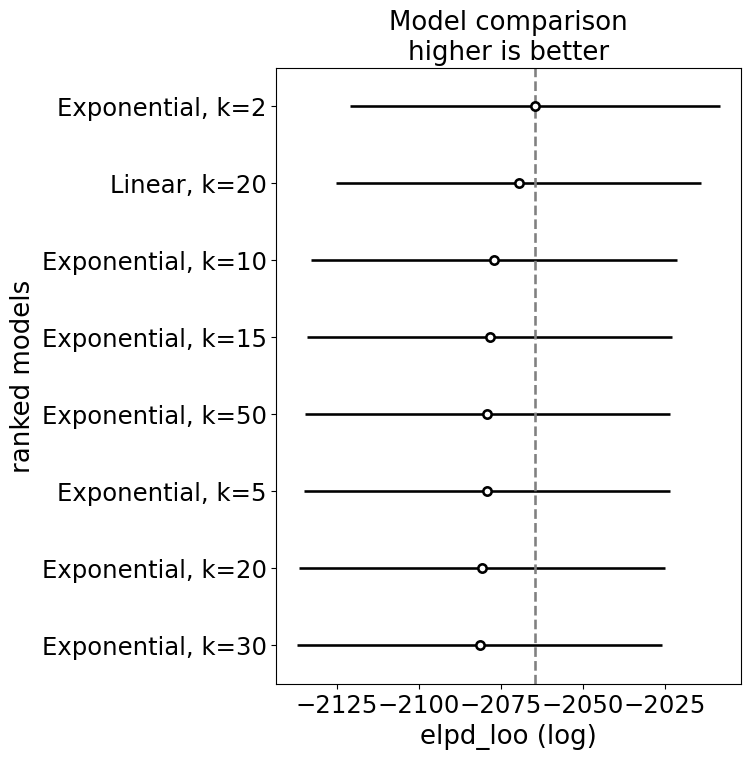

In [10]:
traces = {'Linear, k=20': traces['Linear, k=20']}
for k in [2, 5, 10, 15, 20, 30, 50]:
    if os.path.exists(Path(control_models_path, f"exponential_freq_prior_k{k}.nc")):
        idata = az.from_netcdf(Path(control_models_path, f"exponential_freq_prior_k{k}.nc"))
        traces[f'Exponential, k={k}'] = idata
    else:
        # Compute action priors:
        P_A = []
        for subj in beh_data['vpn'].unique():
            sub_resp = beh_data[beh_data['vpn'] == subj]['response'].to_numpy()
            P_A.append(linear_decay_mvavg(sub_resp, window_size=k, init_val=0.5, kernel="exponential"))
        data = pd.DataFrame(
            {
            'response': beh_data['response'],
            'vpn': beh_data['vpn'],
            'dv': beh_data['dv'],
            'logitP_A': logit(np.clip(np.concatenate(P_A), 1e-3, 1-1e-3))
            }
        )
        action_prior_model = bmb.Model(
            "response ~ dv + logitP_A + dv:logitP_A +"
            " + (dv + logitP_A|vpn)",
                data, 
                family="bernoulli"
            )
        # Add the idata to the rest:
        traces[f'Exponential, k={k}'] = action_prior_model.fit(
            draws=n_samples, tune=n_warmup, chains=n_chains, target_accept=0.85, idata_kwargs={"log_likelihood": True}
        )

        # Save the trace to file:
        az.to_netcdf(traces[f'Exponential, k={k}'], Path(control_models_path, f"exponential_freq_prior_k{k}.nc"))              

# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison                            